In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
!pip install missingno -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")
sns.set_palette("Set2")

In [6]:
path = '/content/drive/MyDrive/Brazilian E-Commerce Public Dataset by Olist/'

orders       = pd.read_csv(path + 'olist_orders_dataset.csv')
order_items  = pd.read_csv(path + 'olist_order_items_dataset.csv')
products     = pd.read_csv(path + 'olist_products_dataset.csv')
customers    = pd.read_csv(path + 'olist_customers_dataset.csv')
sellers      = pd.read_csv(path + 'olist_sellers_dataset.csv')
reviews      = pd.read_csv(path + 'olist_order_reviews_dataset.csv')
payments     = pd.read_csv(path + 'olist_order_payments_dataset.csv')
geolocation  = pd.read_csv(path + 'olist_geolocation_dataset.csv')
category_en  = pd.read_csv(path + 'product_category_name_translation.csv')

for name, df in [('orders', orders), ('items', order_items), ('products', products),
                 ('customers', customers), ('reviews', reviews), ('payments', payments)]:
    print(f"{name}: {df.shape[0]:,} rows × {df.shape[1]} cols")

orders: 99,441 rows × 8 cols
items: 112,650 rows × 7 cols
products: 32,951 rows × 9 cols
customers: 99,441 rows × 5 cols
reviews: 99,224 rows × 7 cols
payments: 103,886 rows × 5 cols


Kiểm tra cấu trúc & missing values

In [7]:
print("=== ORDERS ===")
print(orders.dtypes)
print(orders.isnull().sum())

print("\n=== ORDER ITEMS ===")
print(order_items.dtypes)
print(order_items.isnull().sum())

=== ORDERS ===
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

=== ORDER ITEMS ===
order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64
dtype: object
order_id               0
order_item_id          0
product_id             0
seller_

In [8]:
print("=== TỔNG QUAN MISSING VALUES ===\n")
dfs = {
    'orders': orders, 'order_items': order_items,
    'products': products, 'customers': customers,
    'sellers': sellers, 'reviews': reviews,
    'payments': payments
}

for name, df in dfs.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        print(f"📋 {name.upper()}:")
        for col, count in missing.items():
            pct = count / len(df) * 100
            print(f"   {col}: {count:,} nulls ({pct:.1f}%)")
        print()
    else:
        print(f"✅ {name.upper()}: Không có missing values\n")

=== TỔNG QUAN MISSING VALUES ===

📋 ORDERS:
   order_approved_at: 160 nulls (0.2%)
   order_delivered_carrier_date: 1,783 nulls (1.8%)
   order_delivered_customer_date: 2,965 nulls (3.0%)

✅ ORDER_ITEMS: Không có missing values

📋 PRODUCTS:
   product_category_name: 610 nulls (1.9%)
   product_name_lenght: 610 nulls (1.9%)
   product_description_lenght: 610 nulls (1.9%)
   product_photos_qty: 610 nulls (1.9%)
   product_weight_g: 2 nulls (0.0%)
   product_length_cm: 2 nulls (0.0%)
   product_height_cm: 2 nulls (0.0%)
   product_width_cm: 2 nulls (0.0%)

✅ CUSTOMERS: Không có missing values

✅ SELLERS: Không có missing values

📋 REVIEWS:
   review_comment_title: 87,656 nulls (88.3%)
   review_comment_message: 58,247 nulls (58.7%)

✅ PAYMENTS: Không có missing values



In [9]:
# ── ORDERS ──────────────────────────────────────────
# order_approved_at: 160 nulls → đơn chưa được duyệt
# → Fill bằng order_purchase_timestamp (coi như duyệt ngay lúc đặt)
orders['order_approved_at'] = orders['order_approved_at'].fillna(
    orders['order_purchase_timestamp']
)

# order_delivered_carrier_date: 1783 nulls → đơn chưa giao carrier
# order_delivered_customer_date: 2965 nulls → đơn chưa đến tay khách
# → Những đơn này không phải "delivered" nên giữ nguyên NaN
# → Khi phân tích delivery chỉ dùng filter status='delivered' nên không ảnh hưởng
print("✅ orders: đã xử lý order_approved_at")
print(f"   Còn lại: {orders.isnull().sum().sum()} nulls "
      f"(đều thuộc đơn chưa delivered — hợp lệ)")

# ── PRODUCTS ────────────────────────────────────────
print(f"\n📋 PRODUCTS missing trước xử lý:")
print(products.isnull().sum()[products.isnull().sum() > 0])

# Tên category tiếng Bồ → fill bằng 'unknown'
products['product_category_name'] = products['product_category_name'].fillna('unknown')

# Các cột số (kích thước, cân nặng) → fill bằng median
num_cols = ['product_name_lenght', 'product_description_lenght',
            'product_photos_qty', 'product_weight_g',
            'product_length_cm', 'product_height_cm', 'product_width_cm']
for col in num_cols:
    if col in products.columns:
        median_val = products[col].median()
        products[col] = products[col].fillna(median_val)

print(f"✅ products: đã xử lý")
print(f"   Còn lại: {products.isnull().sum().sum()} nulls")

# ── REVIEWS ─────────────────────────────────────────
print(f"\n📋 REVIEWS missing trước xử lý:")
print(reviews.isnull().sum()[reviews.isnull().sum() > 0])

# review_comment_title & review_comment_message: khách không điền → fill 'no_comment'
reviews['review_comment_title'] = reviews['review_comment_title'].fillna('no_comment')
reviews['review_comment_message'] = reviews['review_comment_message'].fillna('no_comment')

print(f"✅ reviews: đã xử lý")
print(f"   Còn lại: {reviews.isnull().sum().sum()} nulls")

✅ orders: đã xử lý order_approved_at
   Còn lại: 4748 nulls (đều thuộc đơn chưa delivered — hợp lệ)

📋 PRODUCTS missing trước xử lý:
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64
✅ products: đã xử lý
   Còn lại: 0 nulls

📋 REVIEWS missing trước xử lý:
review_comment_title      87656
review_comment_message    58247
dtype: int64
✅ reviews: đã xử lý
   Còn lại: 0 nulls


In [10]:
print("=== SAU XỬ LÝ — TỔNG KẾT ===\n")
all_clean = True
for name, df in dfs.items():
    missing = df.isnull().sum()
    missing_cols = missing[missing > 0]
    if len(missing_cols) > 0:
        print(f"⚠️  {name.upper()} — còn {missing.sum()} nulls:")
        for col, count in missing_cols.items():
            pct = count / len(df) * 100
            print(f"   {col}: {count:,} ({pct:.1f}%) — đơn chưa delivered, hợp lệ")
        all_clean = False
    else:
        print(f"✅ {name.upper()} — sạch hoàn toàn")

if all_clean:
    print("\nToàn bộ dataset đã được xử lý!")
else:
    print("\nCác nulls còn lại đều có lý do hợp lệ, không cần xử lý thêm")

=== SAU XỬ LÝ — TỔNG KẾT ===

⚠️  ORDERS — còn 4748 nulls:
   order_delivered_carrier_date: 1,783 (1.8%) — đơn chưa delivered, hợp lệ
   order_delivered_customer_date: 2,965 (3.0%) — đơn chưa delivered, hợp lệ
✅ ORDER_ITEMS — sạch hoàn toàn
✅ PRODUCTS — sạch hoàn toàn
✅ CUSTOMERS — sạch hoàn toàn
✅ SELLERS — sạch hoàn toàn
✅ REVIEWS — sạch hoàn toàn
✅ PAYMENTS — sạch hoàn toàn

Các nulls còn lại đều có lý do hợp lệ, không cần xử lý thêm


In [11]:
print("=== KIỂM TRA DUPLICATES ===\n")
for name, df in dfs.items():
    dup = df.duplicated().sum()
    status = "✅" if dup == 0 else "⚠️ "
    print(f"{status} {name.upper()}: {dup:,} duplicates")

# Kiểm tra riêng order_id trong orders (phải unique)
print(f"\n📋 order_id unique trong orders: "
      f"{orders['order_id'].nunique():,} / {len(orders):,}")

# Kiểm tra review — 1 order có thể có nhiều review không?
print(f"📋 order_id unique trong reviews: "
      f"{reviews['order_id'].nunique():,} / {len(reviews):,}")

=== KIỂM TRA DUPLICATES ===

✅ ORDERS: 0 duplicates
✅ ORDER_ITEMS: 0 duplicates
✅ PRODUCTS: 0 duplicates
✅ CUSTOMERS: 0 duplicates
✅ SELLERS: 0 duplicates
✅ REVIEWS: 0 duplicates
✅ PAYMENTS: 0 duplicates

📋 order_id unique trong orders: 99,441 / 99,441
📋 order_id unique trong reviews: 98,673 / 99,224


In [12]:
# Giữ review mới nhất cho mỗi order
reviews['review_creation_date'] = pd.to_datetime(reviews['review_creation_date'])

reviews = (reviews
           .sort_values('review_creation_date', ascending=False)
           .drop_duplicates(subset='order_id', keep='first')
           .reset_index(drop=True))

print(f"✅ Reviews sau khi xử lý duplicate: {len(reviews):,} rows")
print(f"   order_id unique: {reviews['order_id'].nunique():,} / {len(reviews):,}")

✅ Reviews sau khi xử lý duplicate: 98,673 rows
   order_id unique: 98,673 / 98,673


## 🧹 Data Cleaning — Tổng kết

### Missing Values
| Dataset | Cột | Nulls | Xử lý |
|---------|-----|-------|-------|
| orders | order_approved_at | 160 (0.2%) | Fill bằng order_purchase_timestamp |
| orders | order_delivered_carrier_date | 1,783 (1.8%) | Giữ nguyên — đơn chưa delivered |
| orders | order_delivered_customer_date | 2,965 (3.0%) | Giữ nguyên — đơn chưa delivered |
| products | product_category_name | 610 (1.9%) | Fill 'unknown' — sản phẩm đã xóa |
| products | các cột số (weight, size) | 2 (0.0%) | Fill median |
| reviews | review_comment_title | 87,656 (88.3%) | Fill 'no_comment' — khách không điền |
| reviews | review_comment_message | 58,247 (58.7%) | Fill 'no_comment' — khách không điền |

### Duplicates
- Toàn bộ 7 bảng: **0 duplicates**
- Reviews: phát hiện **551 đơn có 2 review** → giữ review mới nhất

### Kết quả sau xử lý
- orders: 99,441 rows — 4,748 nulls còn lại hợp lệ
- products: 32,951 rows — **0 nulls**
- reviews: 98,673 rows — **0 nulls**, 0 duplicates
- order_items, customers, sellers, payments: sạch hoàn toàn

Convert datetime

In [13]:
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

orders['year_month'] = orders['order_purchase_timestamp'].dt.to_period('M')
orders['year']       = orders['order_purchase_timestamp'].dt.year
orders['month']      = orders['order_purchase_timestamp'].dt.month
orders['dow']        = orders['order_purchase_timestamp'].dt.day_name()

print("Done! Sample:")
print(orders[['order_purchase_timestamp','year_month','dow']].head(3))

Done! Sample:
  order_purchase_timestamp year_month        dow
0      2017-10-02 10:56:33    2017-10     Monday
1      2018-07-24 20:41:37    2018-07    Tuesday
2      2018-08-08 08:38:49    2018-08  Wednesday


Doanh thu theo tháng

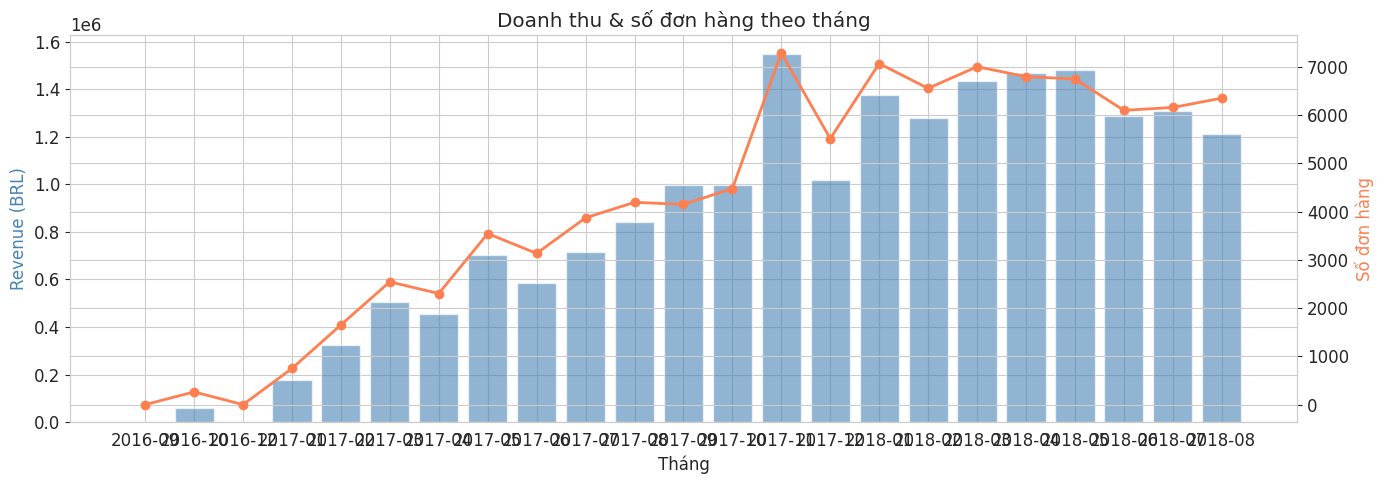

In [14]:
# Merge orders + payments + items để có revenue
df = orders.merge(payments, on='order_id', how='left')
df = df.merge(order_items[['order_id','price','freight_value']], on='order_id', how='left')

df_done = df[df['order_status'] == 'delivered'].copy()

# Revenue theo tháng
monthly = df_done.groupby('year_month').agg(
    revenue=('payment_value', 'sum'),
    num_orders=('order_id', 'nunique')
).reset_index()
monthly['year_month'] = monthly['year_month'].astype(str)

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.bar(monthly['year_month'], monthly['revenue'], color='steelblue', alpha=0.6, label='Revenue (BRL)')
ax2.plot(monthly['year_month'], monthly['num_orders'], color='coral', marker='o', linewidth=2, label='# Orders')

ax1.set_xlabel('Tháng')
ax1.set_ylabel('Revenue (BRL)', color='steelblue')
ax2.set_ylabel('Số đơn hàng', color='coral')
plt.title('Doanh thu & số đơn hàng theo tháng')
plt.xticks(rotation=45, ha='right')
fig.tight_layout()
plt.savefig('monthly_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

Top 10 category

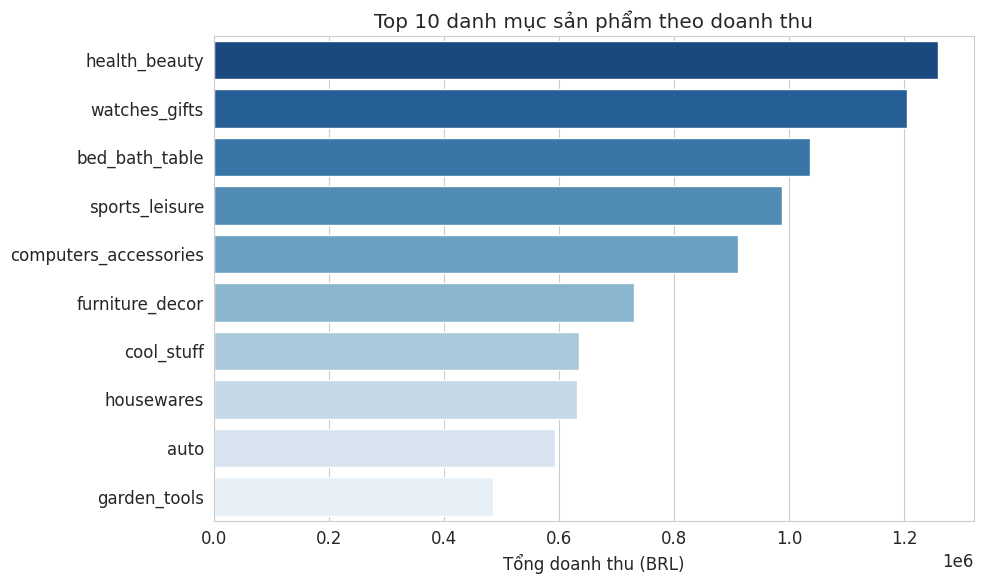

In [15]:
items_cat = order_items.merge(products[['product_id','product_category_name']], on='product_id', how='left')
items_cat = items_cat.merge(category_en, on='product_category_name', how='left')

top_cat = (items_cat.groupby('product_category_name_english')['price']
           .sum()
           .sort_values(ascending=False)
           .head(10)
           .reset_index())

plt.figure(figsize=(10, 6))
sns.barplot(data=top_cat, x='price', y='product_category_name_english', palette='Blues_r')
plt.title('Top 10 danh mục sản phẩm theo doanh thu')
plt.xlabel('Tổng doanh thu (BRL)')
plt.ylabel('')
plt.tight_layout()
plt.savefig('top_categories.png', dpi=150, bbox_inches='tight')
plt.show()

Phân phối review score

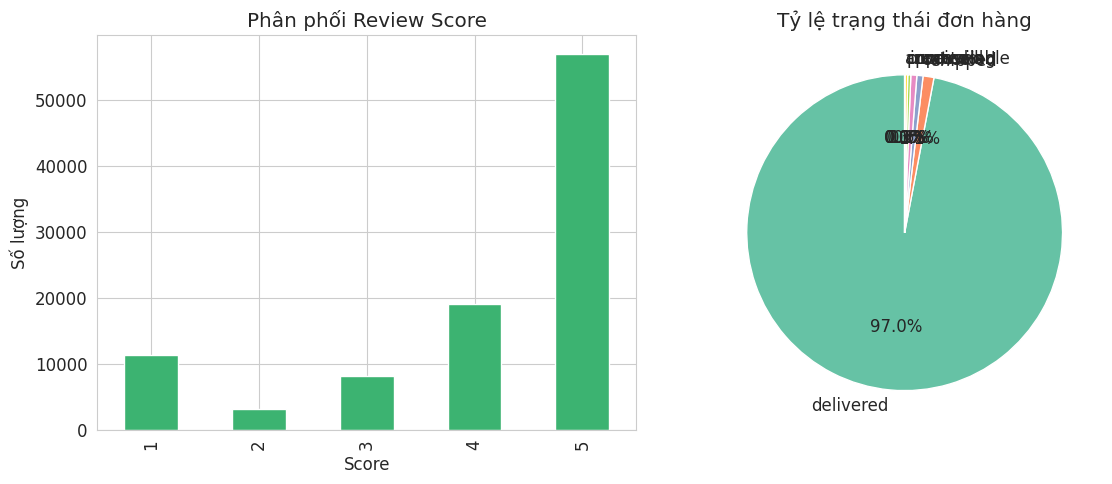

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram review score
reviews['review_score'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='mediumseagreen', edgecolor='white'
)
axes[0].set_title('Phân phối Review Score')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Số lượng')

# Order status breakdown
orders['order_status'].value_counts().plot(
    kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90,
    colors=sns.color_palette('Set2')
)
axes[1].set_title('Tỷ lệ trạng thái đơn hàng')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('overview_stats.png', dpi=150, bbox_inches='tight')
plt.show()

Tính RFM

In [17]:
import datetime

snapshot_date = orders['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
print(f"Snapshot date: {snapshot_date.date()}")

orders_done = orders[orders['order_status'] == 'delivered'].copy()

rfm_df = orders_done.merge(payments[['order_id','payment_value']], on='order_id', how='left')

rfm = rfm_df.groupby('customer_id').agg(
    recency   = ('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
    frequency = ('order_id', 'nunique'),
    monetary  = ('payment_value', 'sum')
).reset_index()

print(rfm.describe().round(2))

Snapshot date: 2018-10-18
        recency  frequency  monetary
count  96478.00    96478.0  96478.00
mean     289.28        1.0    159.85
std      152.84        0.0    218.81
min       50.00        1.0      0.00
25%      165.00        1.0     61.88
50%      270.00        1.0    105.28
75%      399.00        1.0    176.33
max      763.00        1.0  13664.08


Scoring & Segmentation

In [18]:
# Chia điểm 1-5 theo quantile
rfm['R_score'] = pd.qcut(rfm['recency'],   q=5, labels=[5,4,3,2,1])  # thấp hơn = tốt hơn
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5])
rfm['M_score'] = pd.qcut(rfm['monetary'],  q=5, labels=[1,2,3,4,5])

rfm['RFM_score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)
rfm['total_score'] = rfm[['R_score','F_score','M_score']].astype(int).sum(axis=1)

# Segment dựa theo R và F score
def segment(row):
    r, f = int(row['R_score']), int(row['F_score'])
    if r >= 4 and f >= 4: return 'Champions'
    elif r >= 3 and f >= 3: return 'Loyal Customers'
    elif r >= 4 and f <= 2: return 'New Customers'
    elif r <= 2 and f >= 3: return 'At Risk'
    elif r <= 2 and f <= 2: return 'Lost'
    else: return 'Potential'

rfm['segment'] = rfm.apply(segment, axis=1)
print(rfm['segment'].value_counts())

segment
At Risk            23266
Loyal Customers    19243
New Customers      15578
Champions          15378
Lost               15316
Potential           7697
Name: count, dtype: int64


Visualize segments

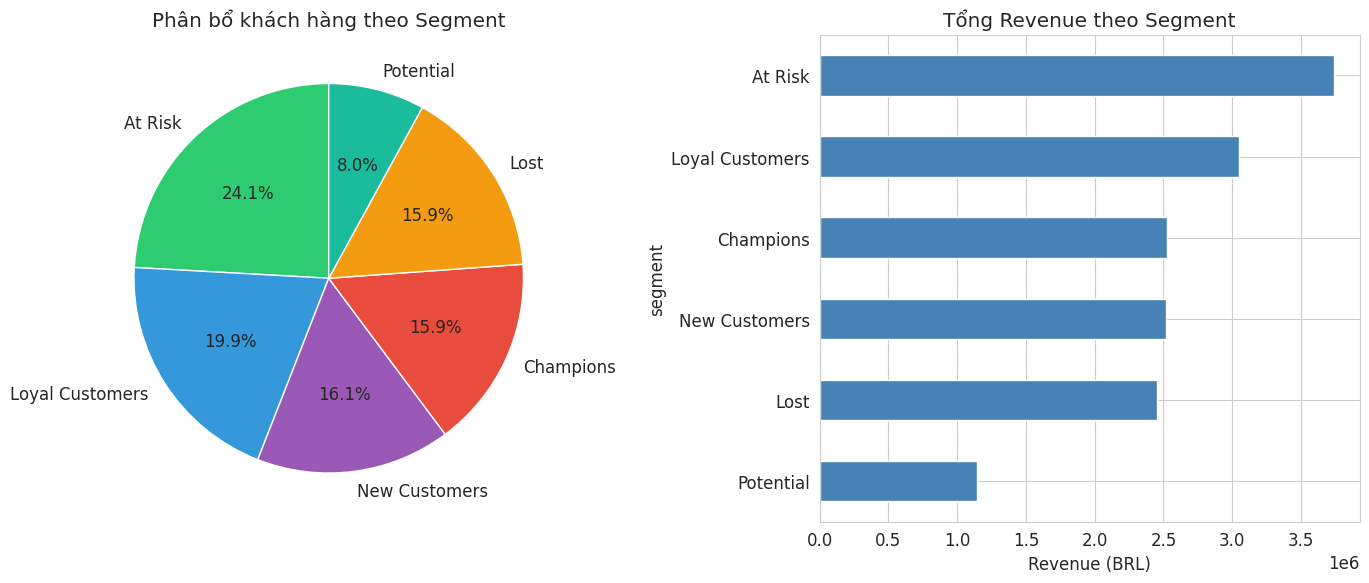

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart số lượng theo segment
seg_count = rfm['segment'].value_counts()
colors = ['#2ecc71','#3498db','#9b59b6','#e74c3c','#f39c12','#1abc9c']
axes[0].pie(seg_count, labels=seg_count.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[0].set_title('Phân bổ khách hàng theo Segment')

# Bar chart revenue theo segment
seg_revenue = rfm.groupby('segment')['monetary'].sum().sort_values(ascending=True)
seg_revenue.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Tổng Revenue theo Segment')
axes[1].set_xlabel('Revenue (BRL)')
plt.tight_layout()
plt.savefig('rfm_segments.png', dpi=150, bbox_inches='tight')
plt.show()

Scatter plot RFM

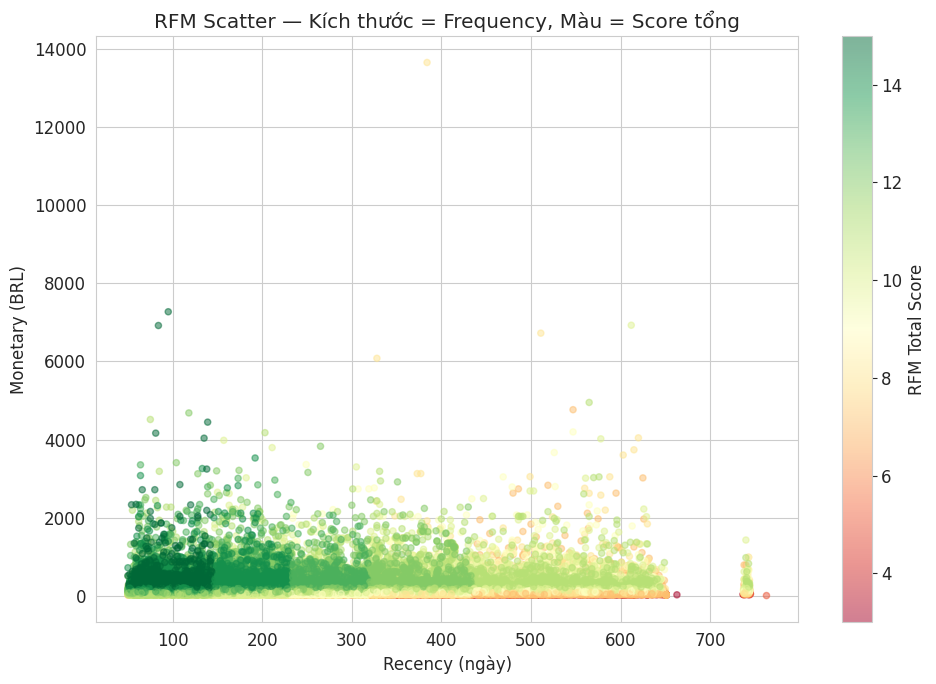

In [20]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    rfm['recency'], rfm['monetary'],
    c=rfm['total_score'], cmap='RdYlGn',
    s=rfm['frequency']*20, alpha=0.5
)
plt.colorbar(scatter, label='RFM Total Score')
plt.xlabel('Recency (ngày)')
plt.ylabel('Monetary (BRL)')
plt.title('RFM Scatter — Kích thước = Frequency, Màu = Score tổng')
plt.tight_layout()
plt.savefig('rfm_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

Delivery Analysis

In [21]:
# Tính delivery time & late flag
orders_done = orders[orders['order_status'] == 'delivered'].copy()
orders_done['delivery_days'] = (
    orders_done['order_delivered_customer_date'] -
    orders_done['order_purchase_timestamp']
).dt.days

orders_done['estimated_days'] = (
    orders_done['order_estimated_delivery_date'] -
    orders_done['order_purchase_timestamp']
).dt.days

orders_done['is_late'] = orders_done['delivery_days'] > orders_done['estimated_days']
orders_done['days_diff'] = orders_done['delivery_days'] - orders_done['estimated_days']

late_rate = orders_done['is_late'].mean() * 100
print(f"Tỷ lệ giao trễ: {late_rate:.1f}%")
print(orders_done[['delivery_days','estimated_days','days_diff']].describe().round(1))

Tỷ lệ giao trễ: 7.6%
       delivery_days  estimated_days  days_diff
count        96470.0         96478.0    96470.0
mean            12.1            23.4      -11.3
std              9.6             8.8       10.2
min              0.0             2.0     -146.0
25%              6.0            18.0      -16.0
50%             10.0            23.0      -12.0
75%             15.0            28.0       -7.0
max            209.0           155.0      189.0


Review score khi TRỄ:    2.46/5
Review score khi ĐÚNG HẠN: 4.29/5
Chênh lệch: 1.83 điểm


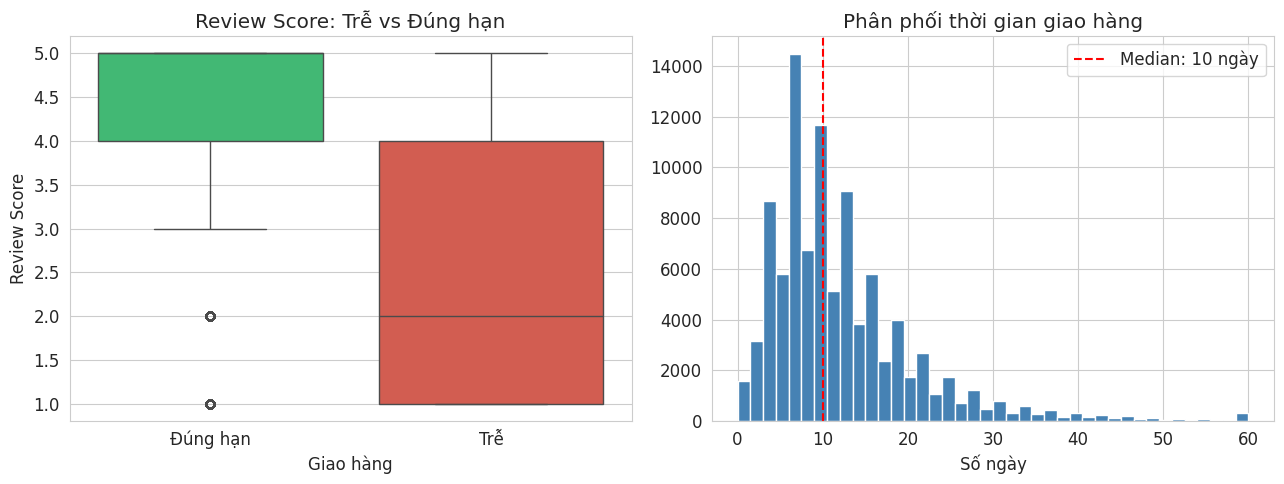

In [28]:
# Late vs On-time → ảnh hưởng review score
df_review = orders_done.merge(reviews[['order_id','review_score']], on='order_id', how='left')

late_review   = df_review[df_review['is_late']  == True]['review_score'].mean()
ontime_review = df_review[df_review['is_late'] == False]['review_score'].mean()

print(f"Review score khi TRỄ:    {late_review:.2f}/5")
print(f"Review score khi ĐÚNG HẠN: {ontime_review:.2f}/5")
print(f"Chênh lệch: {ontime_review - late_review:.2f} điểm")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Box plot review score vs late
df_review['Giao hàng'] = df_review['is_late'].map({True: 'Trễ', False: 'Đúng hạn'})
sns.boxplot(data=df_review, x='Giao hàng', y='review_score',
            palette={'Trễ':'#e74c3c','Đúng hạn':'#2ecc71'}, ax=axes[0])
axes[0].set_title('Review Score: Trễ vs Đúng hạn')
axes[0].set_ylabel('Review Score')

# Histogram delivery days
orders_done['delivery_days'].clip(0,60).hist(
    bins=40, ax=axes[1], color='steelblue', edgecolor='white'
)
axes[1].axvline(orders_done['delivery_days'].median(), color='red',
                linestyle='--', label=f"Median: {orders_done['delivery_days'].median():.0f} ngày")
axes[1].set_title('Phân phối thời gian giao hàng')
axes[1].set_xlabel('Số ngày')
axes[1].legend()

plt.tight_layout()
plt.savefig('delivery_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
import os
output_path = '/content/drive/MyDrive/olist_powerbi_data/'
os.makedirs(output_path, exist_ok=True)

# 1. Monthly revenue (cho trang Overview)
monthly.to_csv(output_path + 'monthly_revenue.csv', index=False)

# 2. Top categories
top_cat.to_csv(output_path + 'top_categories.csv', index=False)

# 3. RFM segments
rfm_export = rfm[['customer_id','recency','frequency','monetary','segment']].copy()
rfm_export['monetary'] = rfm_export['monetary'].round(2)
rfm_export.to_csv(
    output_path + 'rfm_segments.csv',
    index=False,
    float_format='%.2f',
    decimal=','
)

# 4. Delivery analysis
delivery_export = orders_done[['order_id','delivery_days','estimated_days',
                                'days_diff','is_late']].copy()
delivery_export = delivery_export.merge(
    reviews[['order_id','review_score']], on='order_id', how='left')
delivery_export.to_csv(output_path + 'delivery_analysis.csv', index=False)

# 5. Orders tổng hợp (bảng chính)
orders_main = orders_done.merge(
    payments[['order_id','payment_value','payment_type']], on='order_id', how='left')
orders_main = orders_main.merge(
    customers[['customer_id','customer_state','customer_city']], on='customer_id', how='left')
orders_main['year_month'] = orders_main['year_month'].astype(str)
orders_main.to_csv(output_path + 'orders_main.csv', index=False)

print("✅ Đã export xong! Các file:")
for f in os.listdir(output_path):
    size = os.path.getsize(output_path + f) / 1024
    print(f"  {f} — {size:.0f} KB")

✅ Đã export xong! Các file:
  orders_main.csv — 23694 KB
  monthly_revenue.csv — 1 KB
  top_categories.csv — 0 KB
  delivery_analysis.csv — 5270 KB
  rfm_segments.csv — 5464 KB
